In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

print("Libraries imported! ✅")

Libraries imported! ✅


In [4]:
df = pd.read_csv('../data/city_day.csv')
df = df.drop(columns=['Xylene'])
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df = df.dropna(subset=['AQI'])
df['Date'] = pd.to_datetime(df['Date'])

# Use Delhi only
delhi = df[df['City'] == 'Delhi'].sort_values('Date').reset_index(drop=True)

print("Delhi data ready! Shape:", delhi.shape)

Delhi data ready! Shape: (2009, 15)


In [5]:
# Features for anomaly detection
features = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']

X = delhi[features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features prepared!")
print("Looking for anomalies in:", features)

Features prepared!
Looking for anomalies in: ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']


In [6]:
# contamination = how much of data we expect to be anomalies (5%)
isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

# Fit the model
isolation_forest.fit(X_scaled)

# Predict — returns 1 (normal) or -1 (anomaly)
delhi['anomaly'] = isolation_forest.predict(X_scaled)
delhi['anomaly_score'] = isolation_forest.score_samples(X_scaled)

# Count anomalies
total_anomalies = (delhi['anomaly'] == -1).sum()
print(f"Total anomalies detected: {total_anomalies}")
print(f"Out of {len(delhi)} days = {total_anomalies/len(delhi)*100:.1f}% of days")

Total anomalies detected: 101
Out of 2009 days = 5.0% of days


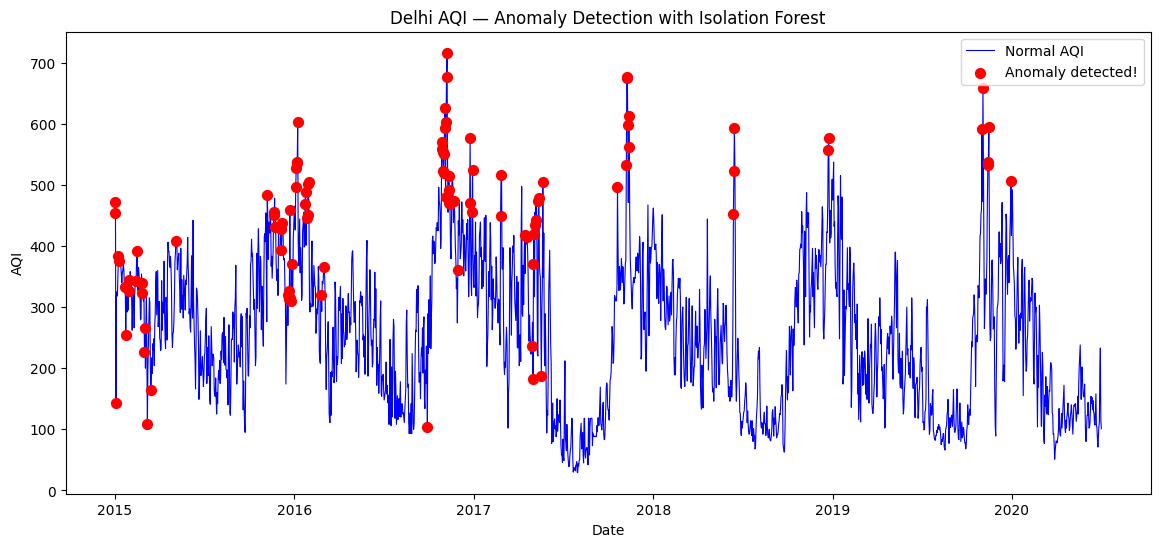

In [7]:
normal = delhi[delhi['anomaly'] == 1]
anomalies = delhi[delhi['anomaly'] == -1]

plt.figure(figsize=(14, 6))
plt.plot(delhi['Date'], delhi['AQI'], 
         color='blue', linewidth=0.8, label='Normal AQI')
plt.scatter(anomalies['Date'], anomalies['AQI'], 
            color='red', s=50, zorder=5, label='Anomaly detected!')
plt.title('Delhi AQI — Anomaly Detection with Isolation Forest')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()

In [8]:
top_anomalies = delhi[delhi['anomaly'] == -1]\
    .sort_values('AQI', ascending=False)\
    [['Date', 'AQI', 'PM2.5', 'CO', 'anomaly_score']]\
    .head(10)

print("Top 10 Most Dangerous Anomaly Days in Delhi:")
print(top_anomalies.to_string())

Top 10 Most Dangerous Anomaly Days in Delhi:
           Date    AQI   PM2.5    CO  anomaly_score
676  2016-11-07  716.0  488.57  2.21      -0.628683
1043 2017-11-09  677.0  495.90  2.37      -0.653875
675  2016-11-06  676.0  685.36  3.23      -0.692365
1042 2017-11-08  675.0  639.19  2.74      -0.679019
1767 2019-11-03  659.0  582.28  2.39      -0.677412
672  2016-11-03  625.0  482.40  2.78      -0.659149
1046 2017-11-12  613.0  465.08  2.44      -0.635497
674  2016-11-05  603.0  588.39  2.20      -0.672507
372  2016-01-08  603.0  339.87  2.34      -0.621391
1044 2017-11-10  597.0  370.73  2.45      -0.576095
